# Regresión Logística
#### UD2. Aprendizaxe Supervisada
#### MP. Sistemas de Aprendizaxe Automáticos
#### IES de Teis (Vigo), Vanesa Resúa Eiras, Cristina Gómez Alonso

En este notebook tomaremos como referencia el material del profesor Dr. Tirthajyoti Sarkar donde demuestra como resolver un problema de regresión logística de predicción de Hipotiroidismo con las librerías **Scikit-learn** y **Statsmodels**.

El dataset es original de UCI ML repository.
<br>Link: https://archive.ics.uci.edu/ml/datasets/Thyroid+

Explicaciones previas:
* [Glándula tiroides](https://es.wikipedia.org/wiki/Gl%C3%A1ndula_tiroides)
* [Hipotiroidismo](https://www.youtube.com/watch?v=RYGjvqrj22Q) minuto 1:53

## 1. Importación de paquetes y dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
names = 'response age sex on_thyroxine query_on_thyroxine antithyroid_medication thyroid_surgery query_hypothyroid query_hyperthyroid pregnant \
sick tumor lithium goitre TSH_measured TSH T3_measured \
T3 TT4_measured TT4 T4U_measured T4U FTI_measured FTI TBG_measured TBG'

In [4]:
names = names.split(' ')

In [5]:
df = pd.read_csv('hypothyroid.csv',index_col=False,names=names,na_values=['?'])

In [6]:
df.head()

,response,age,sex,on_thyroxine,query_on_thyroxine,antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG
0,hypothyroid,72.0,M,f,f,f,f,f,f,f,...,y,0.6,y,15.0,y,1.48,y,10.0,n,NaN
1,hypothyroid,15.0,F,t,f,f,f,f,f,f,...,y,1.7,y,19.0,y,1.13,y,17.0,n,NaN
2,hypothyroid,24.0,M,f,f,f,f,f,f,f,...,y,0.2,y,4.0,y,1.00,y,0.0,n,NaN
3,hypothyroid,24.0,F,f,f,f,f,f,f,f,...,y,0.4,y,6.0,y,1.04,y,6.0,n,NaN
4,hypothyroid,77.0,M,f,f,f,f,f,f,f,...,y,1.2,y,57.0,y,1.28,y,44.0,n,NaN


In [7]:
df.shape

(3163, 26)

## 2. Preprocessing

### 2.1. Borrado de columnas innecesarias

Borraremos todas las features que tienen en su nombre la palabra measured o querey ya que son redundantes.

En el caso concreto del dataset de Hipotiroidismo (y muchos médicos), esas columnas (TSH_measured, T3_measured, TBG_measured, query_...) se borran porque son redundantes (repetidas) y meten ruido.

Estas columnas suelen significar si el médico preguntó o pidió esa prueba, o si el paciente preguntó por ese síntoma (query_on_thyroxine, etc.).

¿Por qué se borran? Porque para saber si estás enfermo biológicamente, lo que importa es el resultado del análisis, no si el médico rellenó el papelito para pedirlo.

A veces, el mero hecho de pedir la prueba ya indica sospecha, pero por lo general se considera "Información Administrativa" y no "Información Clínica". Meten ruido y confunden a la IA.

In [8]:
to_drop=[]
for c in df.columns:
    if 'measured' in c or 'query' in c:
        to_drop.append(c)

In [9]:
to_drop

['query_on_thyroxine',
 'query_hypothyroid',
 'query_hyperthyroid',
 'TSH_measured',
 'T3_measured',
 'TT4_measured',
 'T4U_measured',
 'FTI_measured',
 'TBG_measured']

In [10]:
to_drop.append('TBG')

In [11]:
df.drop(to_drop,axis=1,inplace=True)

In [12]:
df.head()

,response,age,sex,on_thyroxine,antithyroid_medication,thyroid_surgery,pregnant,sick,tumor,lithium,goitre,TSH,T3,TT4,T4U,FTI
0,hypothyroid,72.0,M,f,f,f,f,f,f,f,f,30.0,0.6,15.0,1.48,10.0
1,hypothyroid,15.0,F,t,f,f,f,f,f,f,f,145.0,1.7,19.0,1.13,17.0
2,hypothyroid,24.0,M,f,f,f,f,f,f,f,f,0.0,0.2,4.0,1.00,0.0
3,hypothyroid,24.0,F,f,f,f,f,f,f,f,f,430.0,0.4,6.0,1.04,6.0
4,hypothyroid,77.0,M,f,f,f,f,f,f,f,f,7.3,1.2,57.0,1.28,44.0


Consultamos los valores estadísticos básicos de cada columna. Si añadimos .T a la función 'describe' podemos transponer la matriz resultado y ayuda a la comprensión de dichos valores.

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,2717.0,51.154214,19.294405,1.0,35.00,54.00,67.000,98.00
TSH,2695.0,5.923180,23.899467,0.0,0.00,0.70,2.300,530.00
T3,2468.0,1.939749,0.996773,0.0,1.40,1.80,2.300,10.20
TT4,2914.0,108.850000,45.485419,2.0,83.00,104.00,128.000,450.00
T4U,2915.0,0.978199,0.226580,0.0,0.85,0.96,1.065,2.21
FTI,2916.0,115.397771,60.239572,0.0,91.00,107.00,129.000,881.00


### 2.2. Tratamiento de missing values
La función `df.isna()` retorna un dataframe de valores booleanos (true para indicar la existencia de valor y false para valores missing). Si añadimos la función sum se verán y calcularán el número de missing values para cada columna.

In [14]:
df.isna().sum()

response                    0
age                       446
sex                        73
on_thyroxine                0
antithyroid_medication      0
thyroid_surgery             0
pregnant                    0
sick                        0
tumor                       0
lithium                     0
goitre                      0
TSH                       468
T3                        695
TT4                       249
T4U                       248
FTI                       247
dtype: int64

En este caso borraremos las filas con valores missing ya que desconocemos de conocimiento experto en el área que nos ayude a estimar correctamente dichos valores desconocidos.
No sabemos caunto influirian

In [15]:
df.dropna(inplace=True)

In [16]:
df.shape
df['response'].unique()

array(['hypothyroid', 'negative'], dtype=object)

### 2.3. Transformación de datos categóricos manualmente

La columna **response** contiene los valores 'hypothyroid' para indicar que el paciente sufre hipertiroidismo y 'negative' para indicar que no. Los sustituiremos manualmente por valores numéricos (hypothyroid=1 y negative=0).

In [17]:
def class_convert(response):
    if response=='hypothyroid':
        return 1
    else:
        return 0

In [18]:
df['response']=df['response'].apply(class_convert)

In [19]:
df.head()

,response,age,sex,on_thyroxine,antithyroid_medication,thyroid_surgery,pregnant,sick,tumor,lithium,goitre,TSH,T3,TT4,T4U,FTI
0,1,72.0,M,f,f,f,f,f,f,f,f,30.0,0.6,15.0,1.48,10.0
1,1,15.0,F,t,f,f,f,f,f,f,f,145.0,1.7,19.0,1.13,17.0
2,1,24.0,M,f,f,f,f,f,f,f,f,0.0,0.2,4.0,1.00,0.0
3,1,24.0,F,f,f,f,f,f,f,f,f,430.0,0.4,6.0,1.04,6.0
4,1,77.0,M,f,f,f,f,f,f,f,f,7.3,1.2,57.0,1.28,44.0


In [20]:
df.columns

Index(['response', 'age', 'sex', 'on_thyroxine', 'antithyroid_medication',
       'thyroid_surgery', 'pregnant', 'sick', 'tumor', 'lithium', 'goitre',
       'TSH', 'T3', 'TT4', 'T4U', 'FTI'],
      dtype='object')

## 3. Visual EDA

Se usan para los outlayers que son valores extremos, valores atipicos, los puntos que quedan fuera de la caja, 

### 3.1. Diagrama de cajas

Un diagrama de caja (en inglés boxplot) es un método estandarizado para representar gráficamente una serie de datos numéricos a través de sus cuartiles. De esta manera, se muestran a simple vista la mediana(el valor que ocupa la posición central de un conjunto de observaciones ordenadas) y los cuartiles de los datos, y también pueden representarse sus valores atípicos (o outlayers).
![Explicacion boxplot](./data/box_plot.png) 

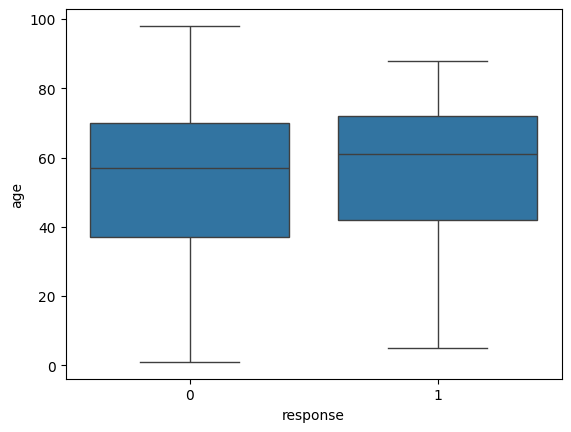

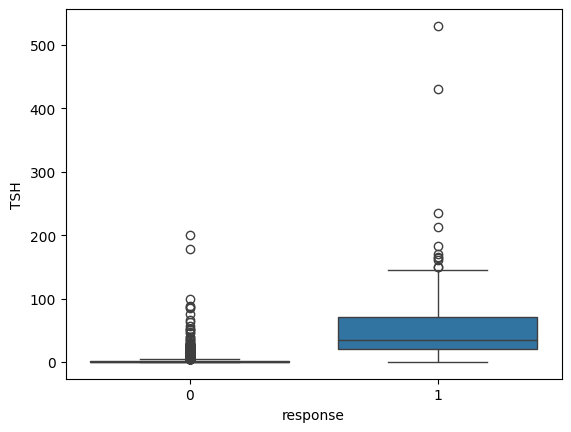

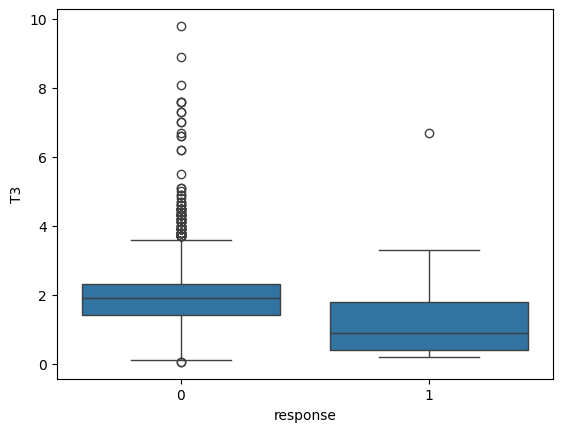

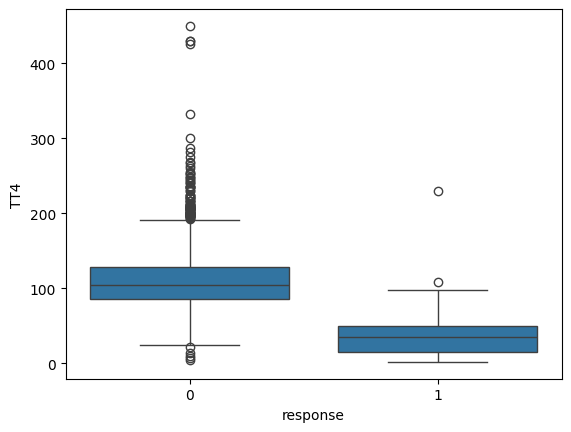

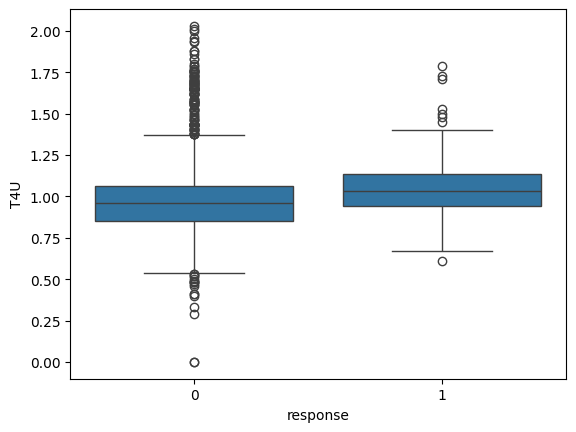

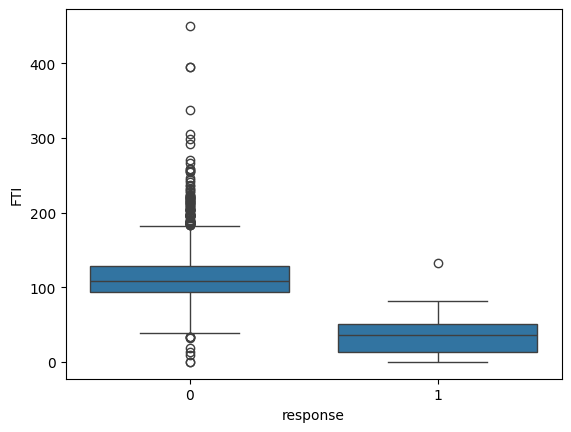

In [21]:
for var in ['age','TSH','T3','TT4','T4U','FTI']:
    sns.boxplot(x='response',y=var,data=df)
    plt.show()

### 3.2. Análisis de correlaciones entre variables independendientes

si le pones el 0, saldria con el target, es ente caso como es 0 1 osea si tiene hihipo o no entocs opor eso sale esas dos lineas :D SEPARADAS 

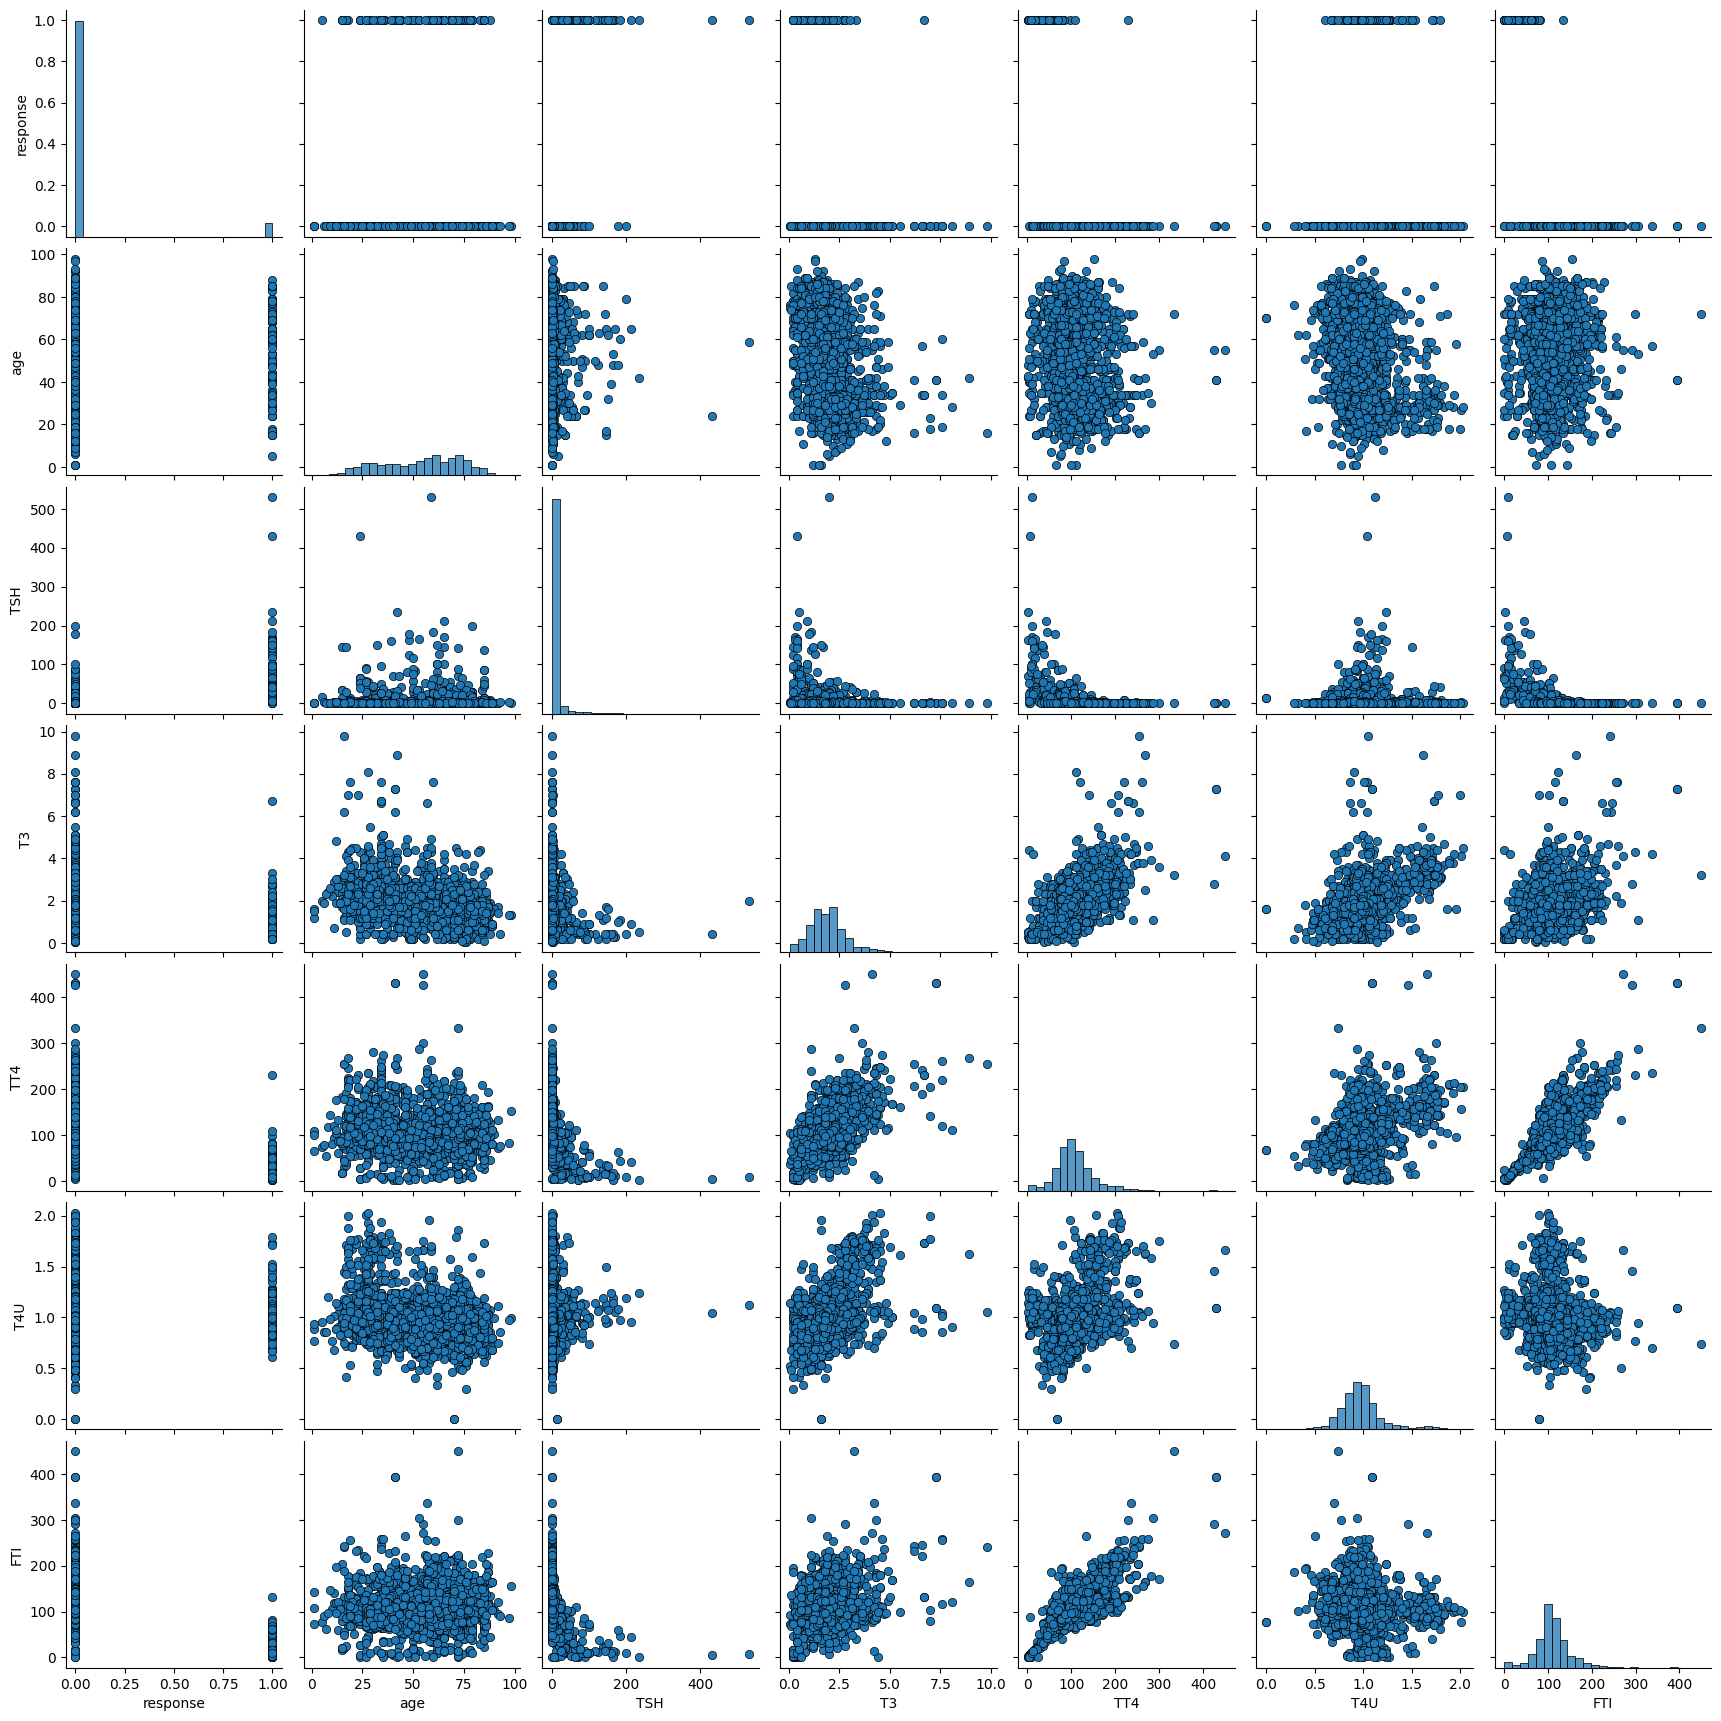

In [22]:
sns.pairplot(data=df[df.columns[0:]],diag_kws={'edgecolor':'k','bins':25},plot_kws={'edgecolor':'k'})
plt.show()

### 3.3. Transformación de datos categóricos con get_dummies

In [23]:
df_dummies = pd.get_dummies(data=df)

In [24]:
df_dummies.shape

(2000, 25)

In [25]:
df_dummies.sample(10)

,response,age,TSH,T3,TT4,T4U,FTI,sex_F,sex_M,on_thyroxine_f,...,pregnant_f,pregnant_t,sick_f,sick_t,tumor_f,tumor_t,lithium_f,lithium_t,goitre_f,goitre_t
1271,0,69.0,0.0,0.9,86.0,0.98,88.0,True,False,True,...,True,False,False,True,True,False,True,False,True,False
968,0,68.0,0.0,1.8,196.0,0.92,213.0,True,False,False,...,True,False,True,False,True,False,True,False,True,False
2936,0,80.0,0.0,1.0,141.0,0.91,154.0,False,True,True,...,True,False,True,False,True,False,True,False,True,False
91,1,34.0,8.7,1.9,59.0,0.92,64.0,False,True,True,...,True,False,True,False,True,False,True,False,True,False
1119,0,37.0,0.0,2.4,109.0,0.90,121.0,False,True,True,...,True,False,True,False,True,False,True,False,True,False
2384,0,27.0,0.0,1.9,167.0,0.77,216.0,True,False,True,...,True,False,True,False,True,False,True,False,True,False
898,0,68.0,0.0,1.1,116.0,0.81,142.0,True,False,True,...,True,False,True,False,True,False,True,False,True,False
2951,0,68.0,0.0,1.6,99.0,0.94,104.0,True,False,False,...,True,False,True,False,True,False,True,False,True,False
653,0,53.0,0.0,2.4,182.0,1.20,152.0,True,False,False,...,True,False,True,False,True,False,True,False,True,False
2567,0,46.0,0.0,1.9,133.0,0.50,266.0,True,False,False,...,True,False,True,False,True,False,True,False,True,False


## 4. División del dataset

La variable X contendrá todas las columnas a excepción de response.
La variable y contendrá exclusivamente la columna response.

In [26]:
from sklearn.model_selection import train_test_split
X = df_dummies.drop('response',axis=1)
y = df_dummies['response']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [27]:
print("Training set shape",X_train.shape)
print("Test set shape",X_test.shape)

Training set shape (1400, 24)
Test set shape (600, 24)


## 5. Creación del modelo de Regresión Logística

Se implementará la regresión logística con regularización Ridge L2(por defecto). [Aquí](https://www.iartificial.net/regularizacion-lasso-l1-ridge-l2-y-elasticnet/) más información sobre los tipos de regularizaciones.

In [28]:
from sklearn.linear_model import LogisticRegression

In [29]:
clf1 = LogisticRegression(penalty='l2')

## 6. Entrenamiento

In [30]:
clf1.fit(X_train,y_train)

/media/a22nicolesdc/DIURNOEXTRA/miniconda3/envs/ML/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## 7. Cálculo de intercept, coefficients y score

In [31]:
clf1.intercept_

array([0.46156948])

In [32]:
clf1.coef_

array([[ 0.02173466,  0.01944165, -0.30031419,  0.00271201,  0.44403068,
        -0.10446619,  0.44234979, -0.19796678,  1.04162012, -0.79723712,
         0.7772387 , -0.53285569, -0.54790282,  0.79228583,  0.31933712,
        -0.07495411,  0.41443294, -0.17004993,  0.41686693, -0.17248392,
         0.29509428, -0.05071127, -0.08695151,  0.33133452]])

In [33]:
clf1.score(X_test,y_test)

0.9816666666666667

## 8. Predicciones

Para las regresiones logísticas, el método `predict_proba` estima la probabilidad de ser de tipo 0 (NO) y la probabilidad de ser de tipo 1(YES).

predict proba , me da un valor , apra ponerlo bonito quieo saber is tiene o ono entoces yo pongo un limite de 0,5 que va ser entre que tenga o no , entoces hago predict probay enfuncionde ese valor sco la decision , le paso el test 

In [34]:
prob_threshold = 0.5

In [35]:
prob_df=pd.DataFrame(clf1.predict_proba(X_test[:10]),columns=['Prob of NO','Prob of YES'])
prob_df['Decision']=(prob_df['Prob of YES']>prob_threshold).apply(int)
prob_df

,Prob of NO,Prob of YES,Decision
0,0.991011,0.008989,0
1,0.998549,0.001451,0
2,0.999999,0.000001,0
3,0.600789,0.399211,0
4,0.999237,0.000763,0
5,0.857734,0.142266,0
6,0.982374,0.017626,0
7,0.998458,0.001542,0
8,0.241910,0.758090,1
9,0.999964,0.000036,0


In [36]:
y_test[:10]

2944    0
511     0
2116    0
1412    0
2039    0
2013    0
1478    0
2744    0
83      1
2100    0
Name: response, dtype: int64

## 9. Informe de classificación (classification report) y matriz de confusión (confusion matrix)

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

In [38]:
print(confusion_matrix(y_test, clf1.predict(X_test)))

[[565   4]
 [  7  24]]


In [39]:
print(classification_report(y_test, clf1.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       569
           1       0.86      0.77      0.81        31

    accuracy                           0.98       600
   macro avg       0.92      0.88      0.90       600
weighted avg       0.98      0.98      0.98       600



tenemos un dataset muy desbalanceado. Hay muchísimos más sanos que enfermos, por eso el modelo tiende a predecir mejor la clase 0
Precision (0.86): La Calidad de la Alarma

Cuando el modelo dice "¡Este paciente está enfermo!", acierta el 86% de las veces.

Interpretación: "El modelo es bastante fiable cuando da la alarma. Tiene pocos Falsos Positivos (falsas alarmas)".

Recall (0.77): La Capacidad de Detección 

De todos los enfermos que había en realidad (los 31), el modelo solo fue capaz de encontrar al 77%.

El cálculo mental: Si había 31 enfermos, el modelo detectó a unos 24 y se le escaparon 7.

Interpretación: "Este es el punto débil. Un Recall de 0.77 significa que estamos dejando escapar a un 23% de los pacientes enfermos sin diagnosticar. En medicina, querríamos que esto fuera más alto".

F1-Score (0.81):

Es la media entre los dos anteriores. Un 0.81 es una nota notable. El modelo es bueno, pero mejorable en sensibilidad.

3. La Clase 0: los sanos 
Precision y Recall (0.99):

El modelo es casi perfecto identificando a la gente sana. No se equivoca casi nunca. Esto es normal porque tiene muchísimos datos (569 ejemplos) para aprender cómo es una persona sana.

4. Accuracy importante
Accuracy (0.98):

Significado: El modelo acierta el 98% de las veces en global.

Interpretación: "Profe, este dato es engañoso. Como casi todo el mundo está sano (Clase 0), el modelo saca muy buena nota global solo con acertar a los sanos. Pero si miramos el detalle de la Clase 1, vemos que 'solo' tiene un 0.81. El Accuracy no refleja la realidad de los enfermos".

-------------
## Ejercicio: Titanic

1. Carga: toma como base el fichero titanic_train.csv y cárgalo.
2. Visual EDA:
   ¿Exiset algún patrón de supervivencia basado en el sexo?
   Crea el siguiente gráfico: sns.countplot(x='Survived',hue='Sex',data=train,palette='RdBu_r')
    ¿Y basado en el clase de los pasajeros (pclass)?
    Crea un histograma que represente la edad de los pasajeros.
    Contrasta la clase respecto a la edad.
3. Preprocessing:
    Sustituye los missing values de la edad por el valor medio.
    Suprime columnas innecesarias.
    Convierte columnas categóricas por variables dummies
4. Creación modelo de regresión logística
5. Entrenamiento
6. Obtén el informe de clasificación y la matriz de confusión.


El target es survive o no, a veces se llama train test.csv, no puedo testear algo sin target el test.csv , nos lo da para resolver si de verda funciona no

sibsp , camtidad dehermanasos esposos
parch cantidcad de padres o ijos a borde


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_titanic = pd.read_csv("titanic_train.csv")
df_titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Cuando hay un patron HAY QUE HACER UNA GRÁFICA SIEMPRE! para explicarlo
Basado en la edad si sobrevivieron 


<Axes: xlabel='Survived', ylabel='count'>

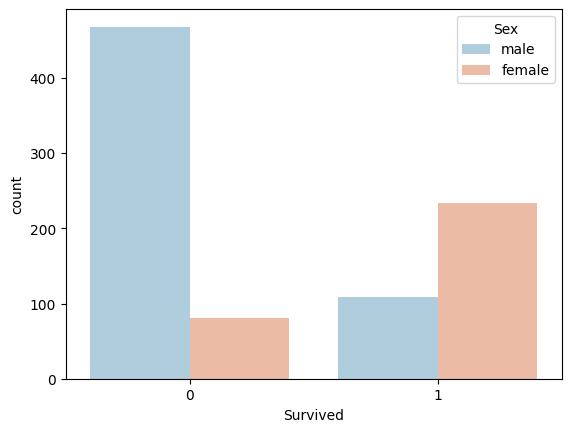

In [41]:
sns.countplot(x='Survived',hue='Sex',data=df_titanic,palette='RdBu_r')

Sobreviven más las mujeres que los hombres

----------

Basado en la clase de los pasajeros

<Axes: xlabel='Survived', ylabel='count'>

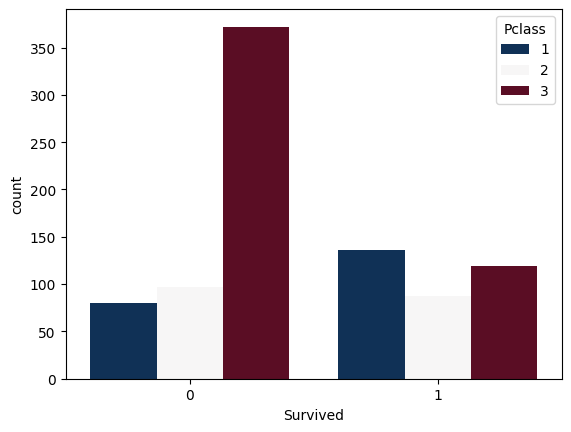

In [42]:
# fig, axes = plt.subplots(1,2, figsize=(10,6))

sns.countplot(x='Survived',hue='Pclass',data=df_titanic,palette='RdBu_r')


La clase 3 influye en que no sobrevivieran 

-----------

Histograma de la edad 

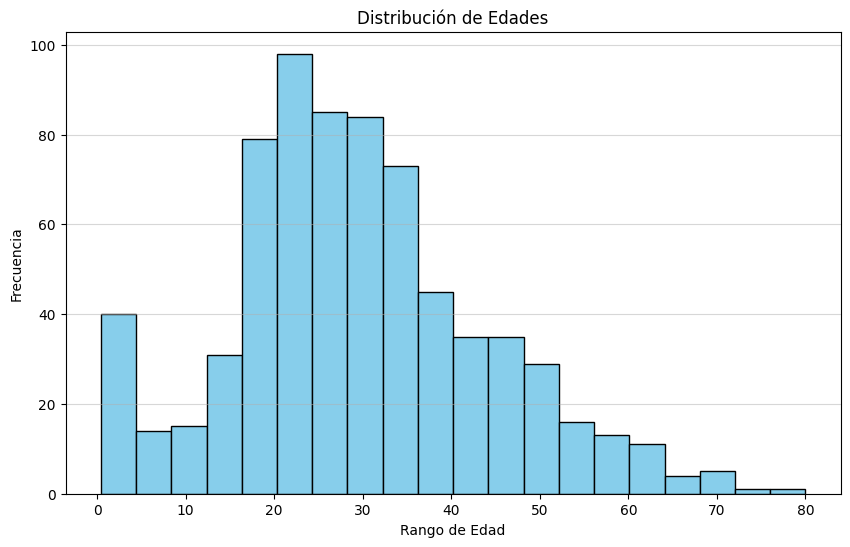

In [43]:
plt.figure(figsize=(10, 6))

df_titanic['Age'].plot(kind='hist', bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de Edades') 
plt.xlabel('Rango de Edad')

plt.ylabel('Frecuencia')

plt.grid(axis='y', alpha=0.5)

plt.show()

La distribución de edades demuestra que la mayoria tenían una edad entre 22 y 30 mayoritariamente 23 aprox

----------
Contrastado por la clase y la edad

/tmp/ipykernel_21009/1779968646.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=df_titanic, palette='winter')


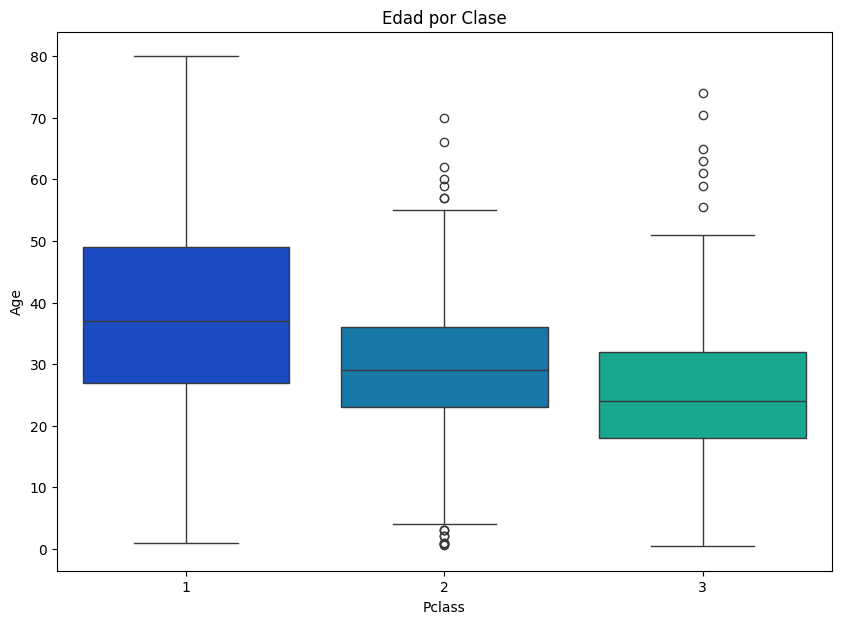

In [44]:

plt.figure(figsize=(10, 7))
sns.boxplot(x='Pclass', y='Age', data=df_titanic, palette='winter')
plt.title('Edad por Clase')
plt.show()

Clase 1: suele rondar los 37-38 años.

Clase 2 :ronda los 29 años.

Clase 3 :ronda los 24 años



-----------
otra forma de hacer las gráficas

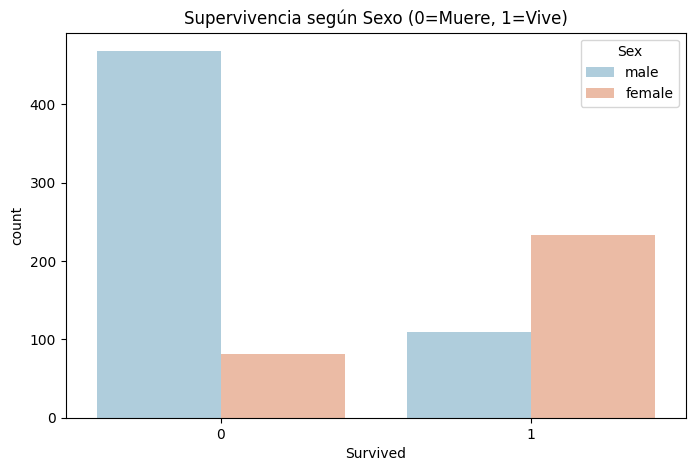

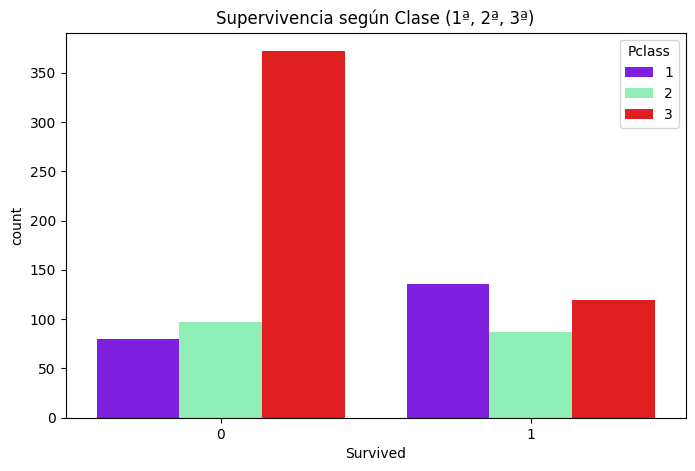

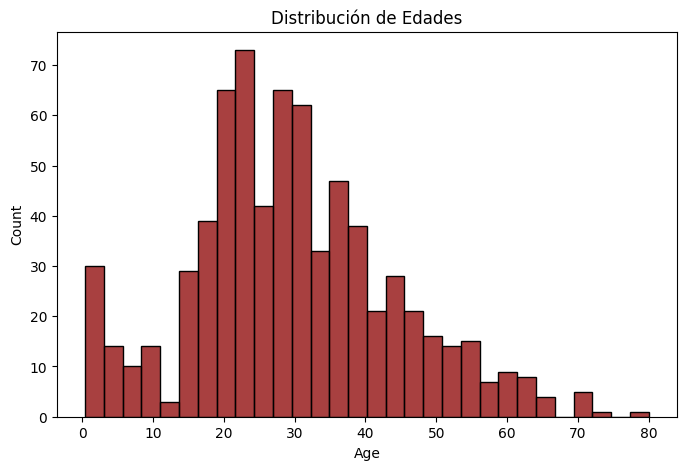

/tmp/ipykernel_21009/1961971271.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=train, palette='winter')


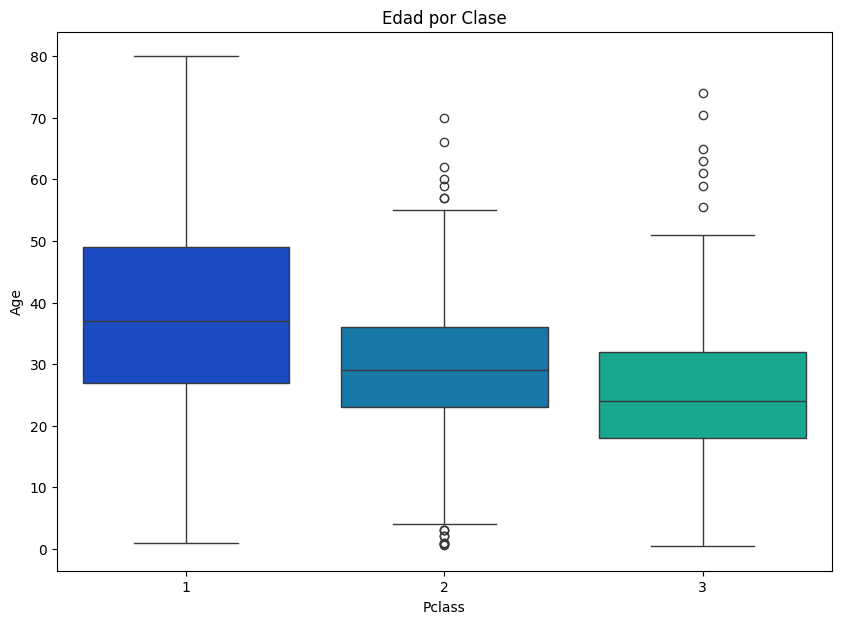

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. CARGA ---
train = pd.read_csv('titanic_train.csv')

# --- 2. VISUAL EDA ---

# A. ¿Patrón de supervivencia basado en el SEXO?
# Copiamos la línea exacta que pedía el ejercicio
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', hue='Sex', data=train, palette='RdBu_r')
plt.title('Supervivencia según Sexo (0=Muere, 1=Vive)')
plt.show()

# B. ¿Patrón basado en la CLASE (Pclass)?
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', hue='Pclass', data=train, palette='rainbow')
plt.title('Supervivencia según Clase (1ª, 2ª, 3ª)')
plt.show()

# C. Histograma de EDAD
plt.figure(figsize=(8, 5))
sns.histplot(train['Age'].dropna(), kde=False, color='darkred', bins=30)
plt.title('Distribución de Edades')
plt.show()

# D. Contraste Clase vs Edad (Boxplot)
plt.figure(figsize=(10, 7))
sns.boxplot(x='Pclass', y='Age', data=train, palette='winter')
plt.title('Edad por Clase')
plt.show()

----------------------------------



Rellenar los valores nulos de edad con la media

In [46]:
df_titanic['Age'].fillna(df_titanic['Age'].mean())

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

---------
Suprimir columnas innecesarias
Cabin tiene muchos nulos y creo que name, ticket, passager id no creyo que influya mucho

In [47]:


df_titanic.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)
df_titanic.dropna(inplace=True)



---------
VARIABLES DUMMIES -> convertir datos categóricos

In [48]:

# el drop_first=True borra la columna repetida y asi nos aseguramos que solo hay una colom con solo saber que t or false en mujer ya sabes qe sexo es
# sex = pd.get_dummies(df_titanic['Sex'], drop_first=True)
# embark = pd.get_dummies(df_titanic['Embarked'], drop_first=True)

# # ahora la añadimos la col
# df_titanic = pd.concat([df_titanic, sex, embark], axis=1)

# # Borramos las columnas de texto originales que ya no sirven
# df_titanic.drop(['Sex', 'Embarked'], axis=1, inplace=True)

# df_titanic.isnull().sum()

df_dummies = pd.get_dummies(data=df_titanic)
df_dummies.shape

(712, 11)

In [49]:
df_dummies.sample(10)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
700,1,1,18.0,1,0,227.5250,True,False,True,False,False
788,1,3,1.0,1,2,20.5750,False,True,False,False,True
281,0,3,28.0,0,0,7.8542,False,True,False,False,True
771,0,3,48.0,0,0,7.8542,False,True,False,False,True
372,0,3,19.0,0,0,8.0500,False,True,False,False,True
761,0,3,41.0,0,0,7.1250,False,True,False,False,True
445,1,1,4.0,0,2,81.8583,False,True,False,False,True
94,0,3,59.0,0,0,7.2500,False,True,False,False,True
276,0,3,45.0,0,0,7.7500,True,False,False,False,True
308,0,2,30.0,1,0,24.0000,False,True,True,False,False


-----------

Antes de crear el modelo de regresion logistica tenemos que dividir el dataset , siempre aorcadrse de no pasrle el target que es lo que quiere predecir 

In [50]:
# tenemos que dividir el dataset 
from sklearn.model_selection import train_test_split
X = df_dummies.drop('Survived',axis=1)
y = df_dummies['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)


In [51]:
print("Training set shape",X_train.shape)
print("Test set shape",X_test.shape)

Training set shape (498, 10)
Test set shape (214, 10)


--------
creacion del modelo:D

In [52]:
from sklearn.linear_model import LogisticRegression
# penalty ? 
clf1 = LogisticRegression(penalty='l2')

----------
Entrenamiento

In [53]:
clf1.fit(X_train,y_train)

/media/a22nicolesdc/DIURNOEXTRA/miniconda3/envs/ML/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


---------
Calculamos el coeficiente, slope, intercepto para poder aplicar la funcion :D, para calcular estos valores se usa el metodo fit()

In [54]:
clf1.intercept_

array([2.41539511])

In [55]:
clf1.coef_

array([[-1.31439277e+00, -3.52734766e-02, -3.22429546e-01,
         5.02461614e-02,  1.36392633e-03,  2.13261960e+00,
        -4.16336983e-01,  8.06314550e-01,  4.14328587e-01,
         4.95639481e-01]])

In [56]:
clf1.score(X_test,y_test)

0.7990654205607477

------------
Entrenamiento:
con método `predict_proba` estima la probabilidad de ser de tipo 0 (NO) y la probabilidad de ser de tipo 1(YES).

In [57]:
prob_threshold = 0.5 # poderia ser otro valor , en este caso pondre 0.5 

In [58]:
prob_df=pd.DataFrame(clf1.predict_proba(X_test[:10]),columns=['Prob of NO','Prob of YES'])
prob_df['Decision']=(prob_df['Prob of YES']>prob_threshold).apply(int)
prob_df

,Prob of NO,Prob of YES,Decision
0,0.035989,0.964011,1
1,0.127919,0.872081,1
2,0.693697,0.306303,0
3,0.038475,0.961525,1
4,0.740969,0.259031,0
5,0.241759,0.758241,1
6,0.593550,0.406450,0
7,0.125323,0.874677,1
8,0.600278,0.399722,0
9,0.417009,0.582991,1


In [59]:
y_test[:10]


641    1
496    1
262    0
311    1
551    0
550    1
279    1
268    1
110    0
554    1
Name: Survived, dtype: int64

---------
Informe de clasificación de la matriz confusión

In [60]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, clf1.predict(X_test)))

[[107  15]
 [ 28  64]]


In [61]:
print(classification_report(y_test, clf1.predict(X_test)))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       122
           1       0.81      0.70      0.75        92

    accuracy                           0.80       214
   macro avg       0.80      0.79      0.79       214
weighted avg       0.80      0.80      0.80       214



Detecta muy bien a las víctimas. Sin embargo, para la Clase 1 es más bajo (0.70), lo que indica que es mas leve a la hora de predecir supervivientes. Esto -->tiene sentido histórico: el perfil de la víctima era muy claro, mientras que la supervivencia tuvo más componentes

In [62]:
#clf1.predict_proba([1,0,22,0,0])

-------------

Probar el modelo :D

In [64]:
import pandas as pd

# Ajustamos los nombres de las columnas a lo que pide TU modelo (clf1)
nuevo_pasajero = pd.DataFrame({
    'Pclass': [2],         # Clase
    'Age': [22],           # Edad
    'SibSp': [0],          # Hermanos
    'Parch': [0],          # Padres/Hijos
    'Fare': [7.25],        # Precio
    
    
    'Sex_male': [0],       # 1 = Es hombre
    'Sex_female': [1],     # 0 = No es mujer (tienes que poner los dos)
    
    'Embarked_Q': [0],     # 0 = No embarcó en Queenstown
    'Embarked_S': [1],     # 1 = Sí embarcó en Southampton
    'Embarked_C': [0]      # 0 = No embarcó en Cherbourg (probablemente te pida este también)
})

# Reordenamos las columnas AUTOMÁTICAMENTE para que coincidan con el entrenamiento
nuevo_pasajero = nuevo_pasajero[clf1.feature_names_in_]


prediccion = clf1.predict_proba(nuevo_pasajero)

print("Predicción:", "Sobrevive 🚢" if prediccion[0] == 1 else "Fallece ☠️")


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

-----

Ahora Con Random Forest

In [67]:
print(clf1.score(X_test, y_test))
print(clf1.score(X_train, y_train))


0.7990654205607477
0.8132530120481928
